In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
from scipy.integrate import quad
import torch
from torch import nn
from datetime import datetime
from matplotlib.gridspec import GridSpec
from tensorboard.backend.event_processing import event_accumulator

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CallbackList
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor 
from stable_baselines3.common.monitor import Monitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../../")

In [3]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.SbAgent import SbAgent
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

In [4]:
seed_value = 42
global seed  
seed = seed_value

# Reset seeds for all randomness sources
np.random.seed(seed)
torch.manual_seed(seed)

import random
random.seed(seed)

base_seed = seed_value
seed_train = base_seed
seed_visualization = base_seed + 1
seed_evaluation = base_seed + 2
seed_test = base_seed + 3

### Parameters

In [5]:
max_inventory = 20

In [6]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [7]:
# OU parameters
u0 = 0.0
xi = 1.0
total_arrivals = 30.0

def m(t, eta):
    return u0 * np.exp(-eta * t)

def v(t, eta):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_aux_integral_for_psi_eta(gamma, eta, fads_proportion):
    """Compute psi for multiple eta values using the discretized integral version."""
    time_grid = np.linspace(0, terminal_time, n_steps)

    v_t = v(time_grid, eta)
    c = gamma * sigma * fads_proportion
    integrand_values = np.exp((c**2) / 2 * v_t)
    aux_integral = terminal_time * np.mean(integrand_values)
    psi = (total_arrivals * terminal_time - phi * terminal_time) / aux_integral

    return psi

psi = compute_aux_integral_for_psi_eta(gamma, eta, fads_proportion)
print("psi value:", psi)

psi value: 14.872343376978963


In [8]:
def get_closed_form_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [9]:
cj_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [10]:
cj_agent = ModifiedCarteaJaimungalMmAgent(env=cj_env)
print(cj_env.model_dynamics
      .midprice_model)


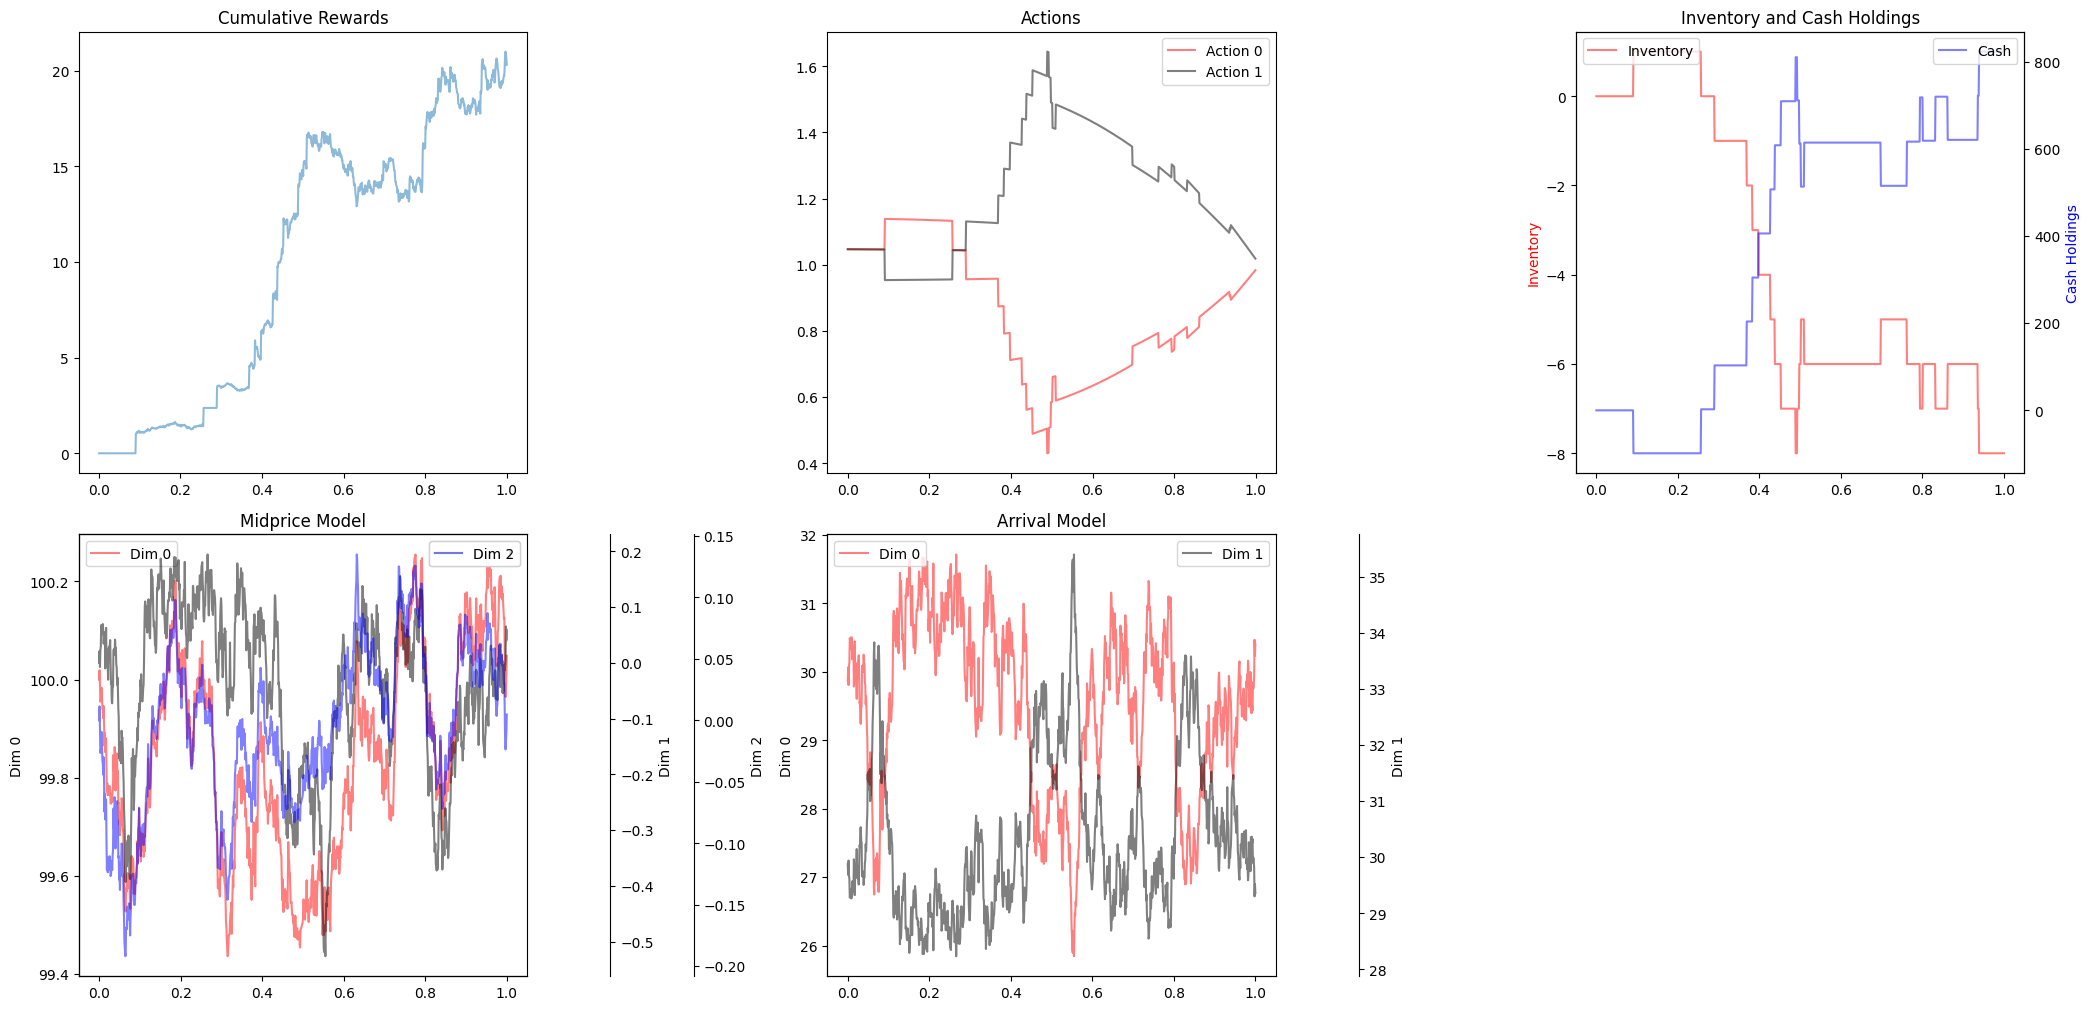

In [11]:
plot_trajectory_extended(cj_env, cj_agent)

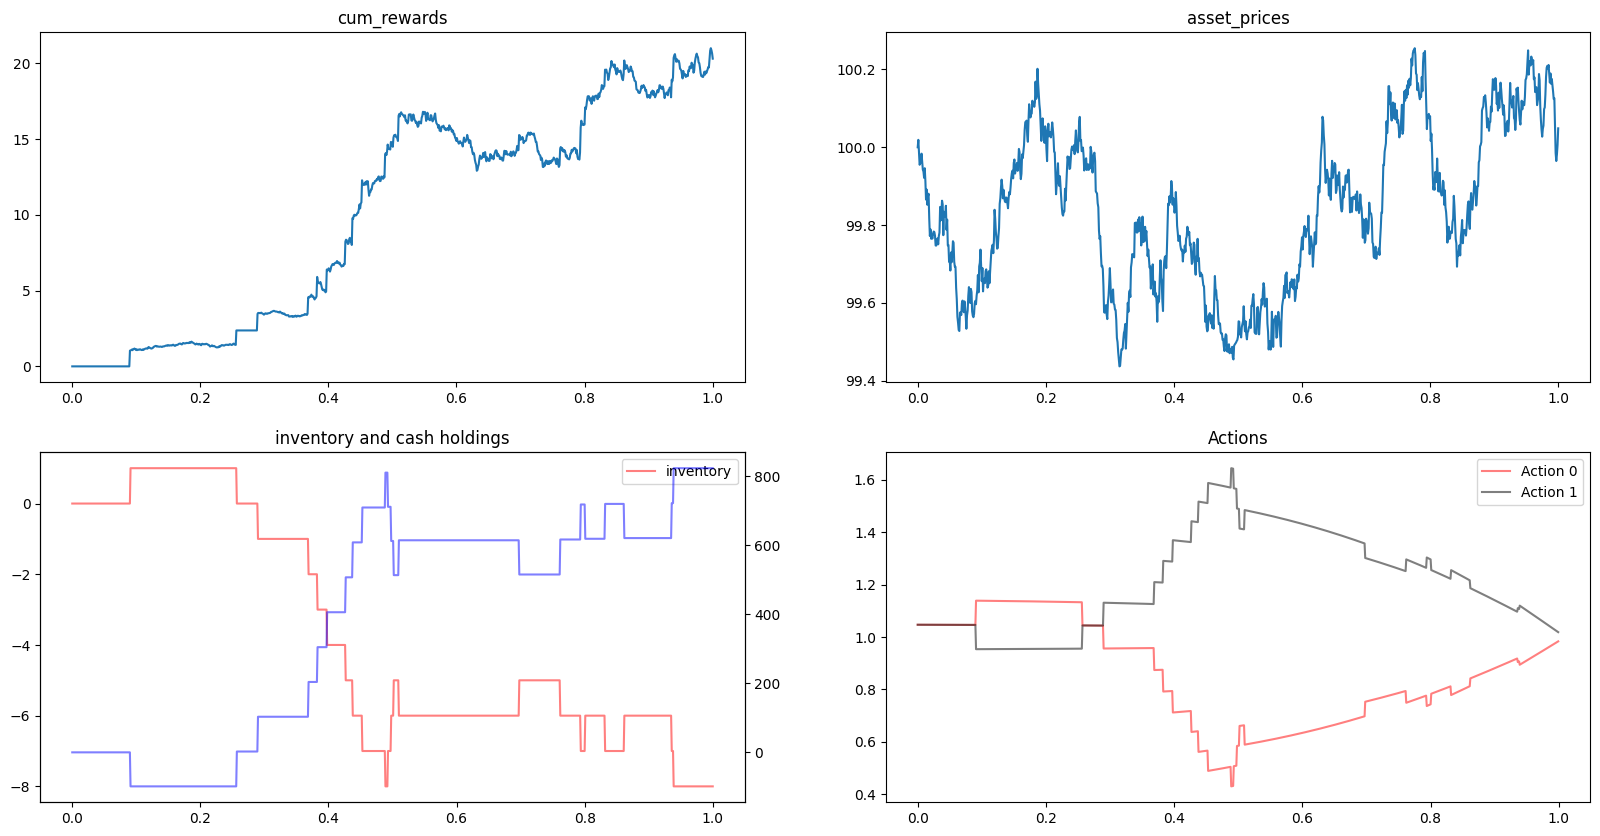

In [12]:
plot_trajectory(cj_env, cj_agent, seed = seed)

In [13]:
num_trajectories = 1000
vec_cj_env = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_cj = ModifiedCarteaJaimungalMmAgent(env=vec_cj_env)

In [14]:
observations_cj, actions_cj, rewards_cj = generate_trajectory(vec_cj_env, vec_cj)

In [15]:
results_cj, fig_cj, total_rewards_cj = generate_results_table_and_hist(vec_env=vec_cj_env,agent=vec_cj)

In [16]:
results_cj

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065896,21.133681,4.809688,-0.071,3.106116


### Rinforncement Learning

#### Random initial inventory

In [17]:
random_initial_inventory = (-6,5)

#### Random start time 

In [18]:
def make_random_start_time_sampler(terminal_time: float):
    """
    Returns a callable that samples an initial time according to:
      - with probability 0.5: uniform in [0, 0.8 * T]
      - with probability 0.5: uniform in [0.8 * T, 0.99 * T]
    
    Parameters
    ----------
    terminal_time : float
        The terminal time T of the episode.
    
    Returns
    -------
    callable
        A function that samples and returns a random start time.
    """
    def _sample_start_time():
        if np.random.rand() < 0.5:
            # 50% chance: early part of episode
            return np.random.uniform(0.0, 0.8 * terminal_time)
        else:
            # 50% chance: near the end of episode
            return np.random.uniform(0.8 * terminal_time, 0.99 * terminal_time)
    return _sample_start_time

In [19]:
def get_rl_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0, seed:int = seed_value
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [20]:
num_trajectories = 1000
reduced_training_indices = [INVENTORY_INDEX, TIME_INDEX, ASSET_PRICE_INDEX]
rl_env_train = ReduceStateSizeWrapper(get_rl_env(num_trajectories, seed=seed_train), reduced_training_indices)
#rl_env = NormaliseASObservation(rl_env)
sb_rl_env_train = StableBaselinesTradingEnvironment(trading_env=rl_env_train)

# Monitor sb_rl_env
sb_rl_env_train = VecMonitor(sb_rl_env_train)

/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:225: RuntimeWarning: overflow encountered in cast
  elif low.dtype != self.dtype and np.any(low < dtype_min):
/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/gymnasium/spaces/box.py:295: RuntimeWarning: overflow encountered in cast
  elif high.dtype != self.dtype and np.any(dtype_max < high):


In [ ]:
rl_env_eval = ReduceStateSizeWrapper(get_rl_env(num_trajectories=1000, seed=seed_evaluation), reduced_training_indices)
sb_rl_env_eval = StableBaselinesTradingEnvironment(trading_env=rl_env_eval)
# Monitor sb_env_eval
sb_rl_env_eval = VecMonitor(sb_rl_env_eval)

### PPO

In [22]:
total_steps = num_trajectories * n_steps * 10 

n_eval_episodes = 256

eval_freq = n_steps * 1

use_normalized_agent = False

In [23]:
# Generate timestamp string
run_id = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
experiment_name = "CjMm_final_version_prova"
# Paths with timestamp
tensorboard_logdir = f".././CJ_models/tensorboard/PPO-learning/{experiment_name}/{run_id}/"
best_model_path = f".././CJ_models/PPO-best/{experiment_name}/{run_id}/"

In [24]:
print(sb_rl_env_train.action_space)
print(sb_rl_env_train.action_space.low, sb_rl_env_train.action_space.high)

Box(0.0, 4.6051702, (2,), float32)
[0. 0.] [4.6051702 4.6051702]


In [25]:
print(sb_rl_env_train)

In [26]:
class EntropyDecayCallback(BaseCallback):
    def __init__(self, initial_ent_coef=0.05, final_ent_coef=0.001, decay_steps=10_000_000, verbose=0):
        super().__init__(verbose)
        self.initial_ent_coef = initial_ent_coef
        self.final_ent_coef = final_ent_coef
        self.decay_steps = decay_steps

    def _on_step(self) -> bool:
        progress = min(1.0, self.num_timesteps / self.decay_steps)
        new_ent_coef = self.initial_ent_coef * (1 - progress) + self.final_ent_coef * progress
        self.model.ent_coef = new_ent_coef
        return True

In [27]:
from stable_baselines3.common.callbacks import ProgressBarCallback

In [28]:
policy_kwargs = dict(
    activation_fn=nn.Tanh,                 
    net_arch=[dict(pi=[256, 256], vf=[256, 256])]
)

n_epochs = 10
learning_rate = 3e-4
gae_lambda = 0.95
clip_range = 0.2
vf_coef = 0.5
max_grad_norm = 0.5

PPO_params = {"policy":'MlpPolicy', "env": sb_rl_env_train, "verbose":1, 
              "policy_kwargs":policy_kwargs, 
              "tensorboard_log":tensorboard_logdir,
              "n_epochs":n_epochs,
              "batch_size": int(n_steps * num_trajectories / 10), 
              "n_steps": int(n_steps),
              "learning_rate": learning_rate,
              "gae_lambda": gae_lambda,
              "clip_range": clip_range,
              "vf_coef": vf_coef,
              "max_grad_norm": max_grad_norm,
                }

#eval_env = get_rl_env(num_trajectories=1)
#eval_env.initial_inventory = 0
callback_params = dict(eval_env=sb_rl_env_eval, n_eval_episodes=n_eval_episodes,
                       eval_freq=eval_freq,
                       best_model_save_path = best_model_path, 
                       deterministic=True)

entropy_decay_callback = EntropyDecayCallback(initial_ent_coef=0.05, final_ent_coef=0.001, decay_steps=20_000_000)
callback = CallbackList([EvalCallback(**callback_params), entropy_decay_callback])

#callback = EvalCallback(**callback_params)
model = PPO(**PPO_params, device="cpu")

Using cpu device


/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


### Training

In [29]:
print(sb_rl_env_train.observation_space)

Box([-20.          0.         -5.5999999], [ 20.           1.         105.59999847], (3,), float64)


In [30]:
model.learn(total_timesteps = total_steps, callback=callback, progress_bar=True) 

Logging to .././CJ_models/tensorboard/PPO-learning/CjMm_final_version_prova/2025-12-01_11-52-23/PPO_1


Output()

Eval num_timesteps=1000000, episode_reward=-3.46 +/- 6.14

Episode length: 1000.00 +/- 0.00

---------------------------------
| eval/              |          |
|    mean_ep_length  | 1e+03    |
|    mean_reward     | -3.46    |
| time/              |          |
|    total_timesteps | 1000000  |
---------------------------------


...

Eval num_timesteps=10000000, episode_reward=9.88 +/- 4.25

Episode length: 1000.00 +/- 0.00

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 1e+03        |
|    mean_reward          | 9.88         |
| time/                   |              |
|    total_timesteps      | 10000000     |
| train/                  |              |
|    approx_kl            | 0.0017008461 |
|    clip_fraction        | 0.0107       |
|    clip_range           | 0.2          |
|    entropy_loss         | -3.27        |
|    explained_variance   | 0.232        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.0352       |
|    n_updates            | 90           |
|    policy_gradient_loss | -0.000461    |
|    std                  | 1.25         |
|    value_loss           | 0.255        |
------------------------------------------


New best mean reward!

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 8.1      |
| time/              |          |
|    fps             | 22666    |
|    iterations      | 10       |
|    time_elapsed    | 441      |
|    total_timesteps | 10000000 |
---------------------------------


### Visualization

In [31]:
def get_rl_env_visualization(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0, seed:int = seed_value
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      #initial_inventory = random_initial_inventory,
                      #start_time = make_random_start_time_sampler(terminal_time),
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory = max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [32]:
rl_env_visualization = get_rl_env_visualization(num_trajectories=5, seed=seed_visualization)

In [33]:
ppo_agent = SbAgent(model, reduced_training_indices=reduced_training_indices, env=rl_env_visualization, use_normalized_agent=use_normalized_agent)

Generating RL trajectory plot...
env.observation_space: Box([-1.056e+05 -2.000e+01  0.000e+00 -5.600e+00 -1.000e+01 -1.000e+01
  0.000e+00  0.000e+00], [1.056e+05 2.000e+01 1.000e+00 1.056e+02 1.000e+01 1.000e+01 6.000e+01
 6.000e+01], (8,), float32)
env.action_space: Box(0.0, 4.6051702, (2,), float32)


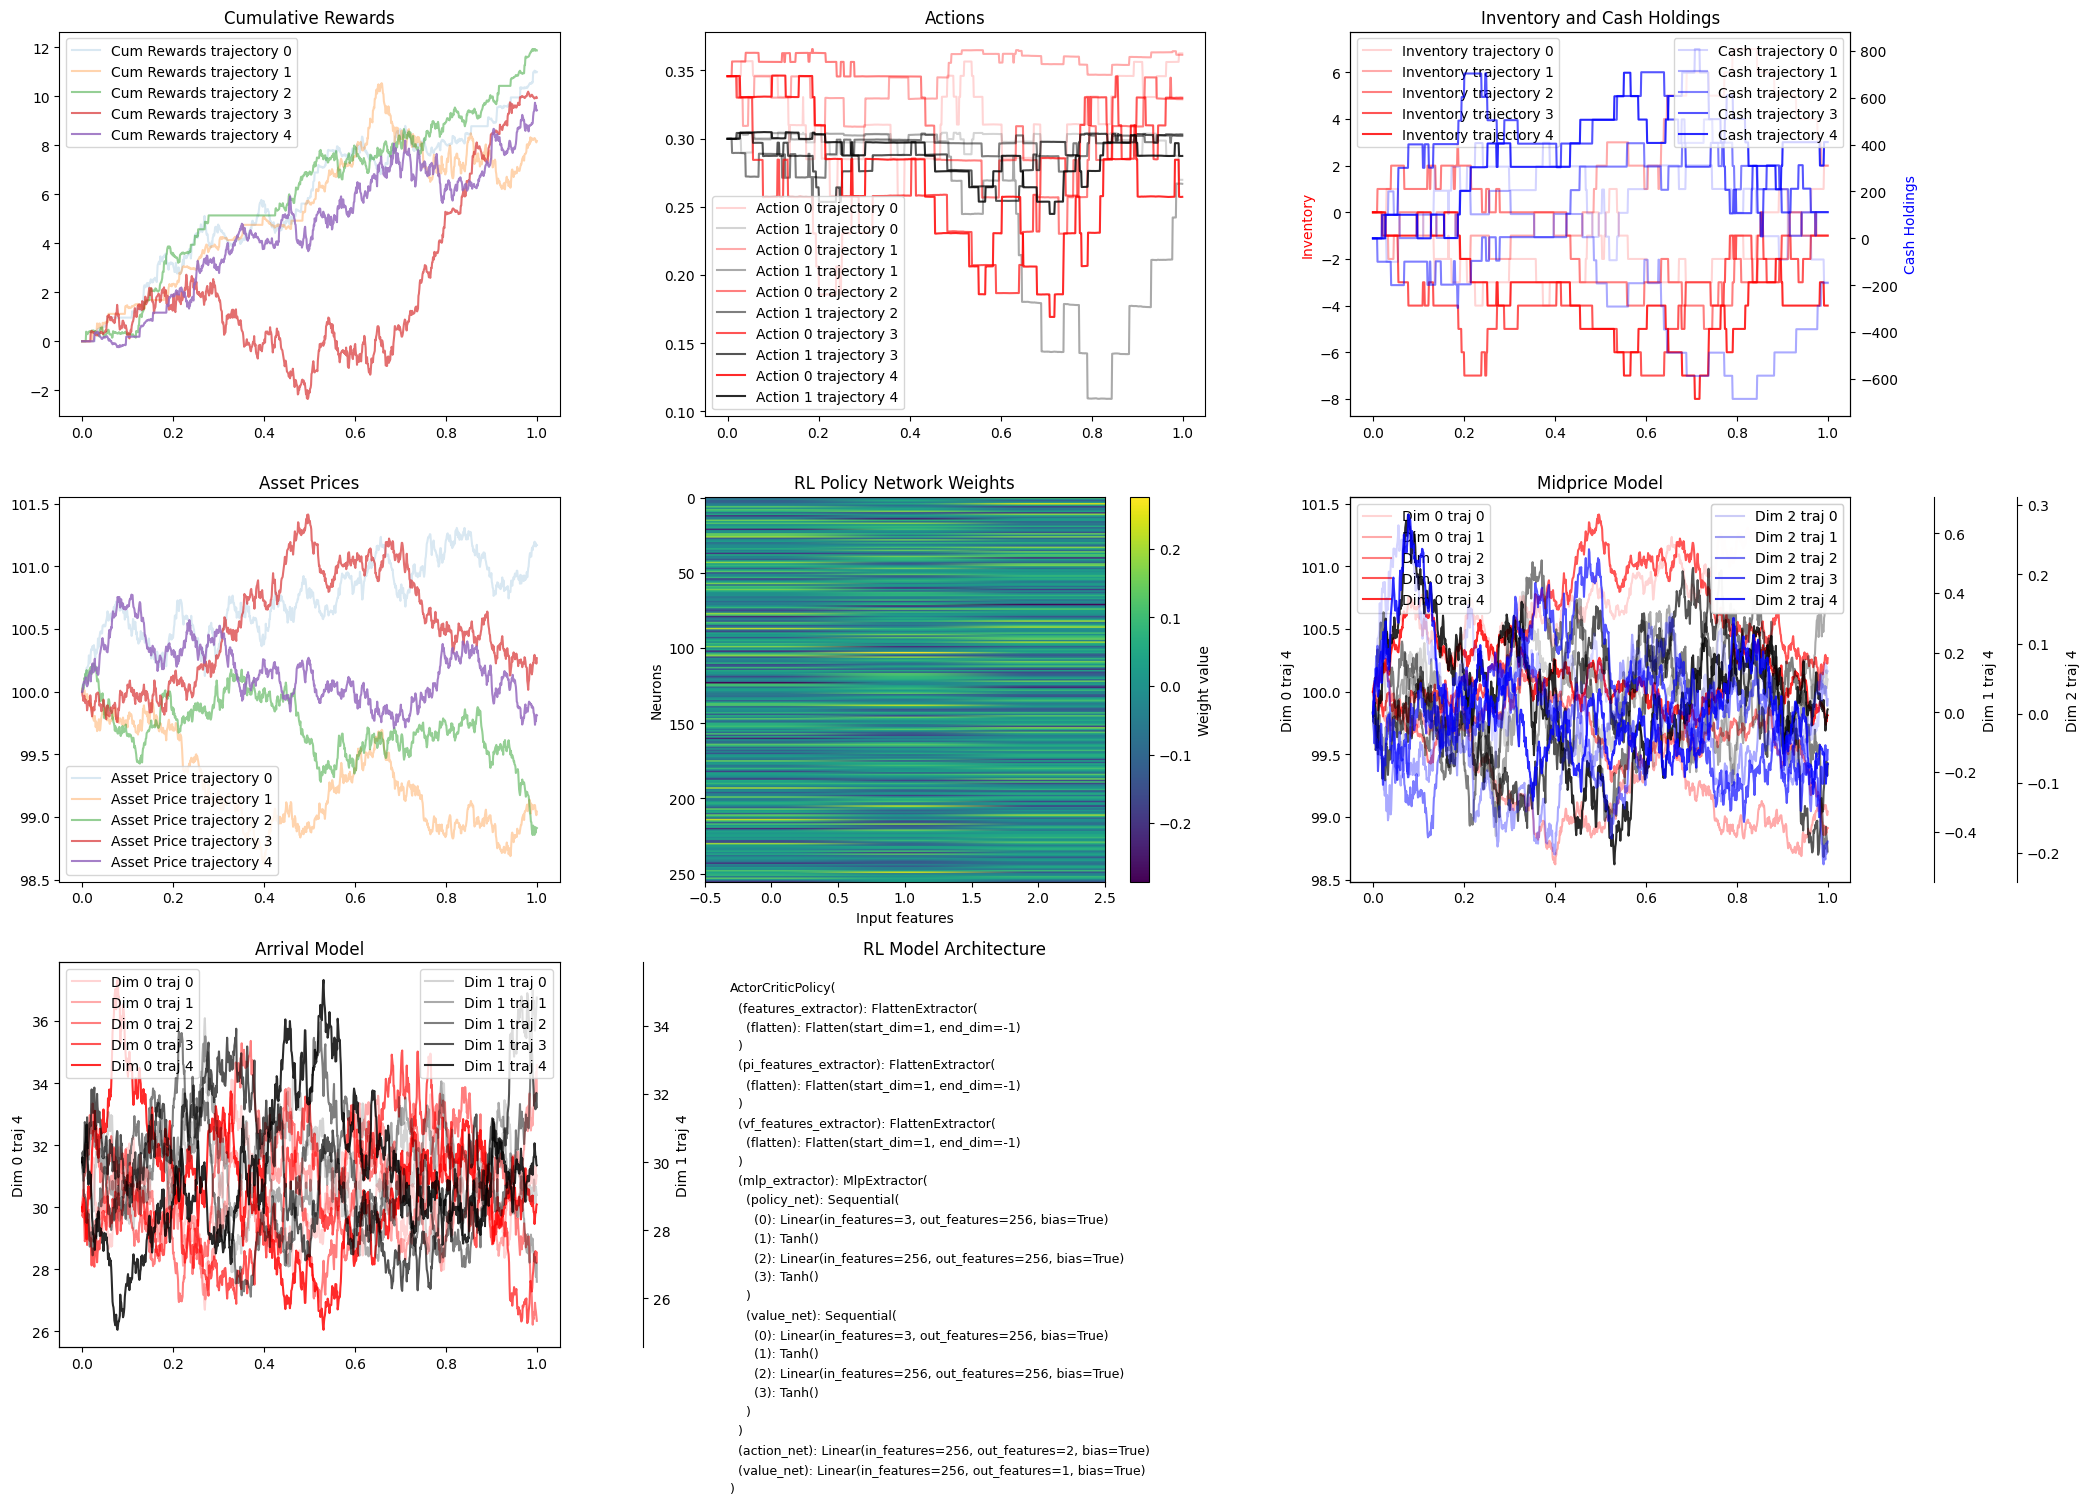

Plot saved to .././CJ_models/PPO-best/CjMm_final_version_prova/2025-12-01_11-52-23/trajectory_plot.png


In [34]:
# Ensure the directory exists
os.makedirs(best_model_path, exist_ok=True)

# Create the plot
fig = plot_rl_trajectory_extended(rl_env_visualization, ppo_agent)

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "trajectory_plot.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

In [35]:
rl_env_evaluation = get_rl_env_visualization(num_trajectories=1000, seed=seed_test)

In [36]:
results_rl, fig_rl, total_rewards_rl = generate_results_table_and_hist_rl_fast(vec_env=rl_env_evaluation, rl_agent=ppo_agent, use_normalized_agent=use_normalized_agent)

In [37]:
results_rl

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
RL Agent,0.578325,10.942468,4.731074,-1.235,5.608723


## Comparing the learnt policy to the optimal policy

In [38]:
# For the StableBaselinesTradingEnvironment
print("SB Environment Action Space:")
print(f"Shape: {sb_rl_env_train.action_space}")
print(f"Low bounds: {sb_rl_env_train.action_space.low}")
print(f"High bounds: {sb_rl_env_train.action_space.high}")

# For the original trading environment
print("\nOriginal Trading Environment Action Space:")
print(f"Shape: {rl_env_train.action_space}")
print(f"Low bounds: {rl_env_train.action_space.low}")
print(f"High bounds: {rl_env_train.action_space.high}")

SB Environment Action Space:
Shape: Box(0.0, 4.6051702, (2,), float32)
Low bounds: [0. 0.]
High bounds: [4.6051702 4.6051702]

Original Trading Environment Action Space:
Shape: Box(0.0, 4.6051702, (2,), float32)
Low bounds: [0. 0.]
High bounds: [4.6051702 4.6051702]


In [39]:
# Auxiliary function for normalization of inventories
def normalize_inventory(inventories, max_inventory, use_normalized=False, inverse=False):
    if not use_normalized:
        return inventories

    inventory_low = -max_inventory
    gradient_inventory = (max_inventory - inventory_low) / 2 

    if inverse:
        return (inventories + 1) * gradient_inventory + inventory_low
    else:
        return (inventories - inventory_low) / gradient_inventory - 1

In [40]:
inventories = np.arange(-4,5,1)
inventories_normalised = normalize_inventory(inventories, max_inventory, use_normalized=use_normalized_agent, inverse=False)

In [41]:
ppo_agent = SbAgent(model, reduced_training_indices=reduced_training_indices, env=rl_env_evaluation, use_normalized_agent=use_normalized_agent) 

In [42]:
bid_actions = []
ask_actions = []
for inventory in inventories_normalised:
    if use_normalized_agent:
        state = np.array([[inventory,0,0]])
    else:
        state = np.array([[inventory,0.5,100]])
    bid_action, ask_action = ppo_agent.get_action(state).reshape(-1)
    bid_actions.append(bid_action)
    ask_actions.append(ask_action)    

In [43]:
cj_agent = ModifiedCarteaJaimungalMmAgent(env=get_closed_form_env())

In [44]:
# Get the Cartea Jaimungal action
cj_bid_actions = []
cj_ask_actions = []
for inventory in inventories:
    bid_action, ask_action = cj_agent.get_action(np.array([[0,inventory,0.5]])).reshape(-1)
    cj_bid_actions.append(bid_action)
    cj_ask_actions.append(ask_action)

Policy comparison plot saved to .././CJ_models/PPO-best/CjMm_final_version_prova/2025-12-01_11-52-23/policy_comparison.png


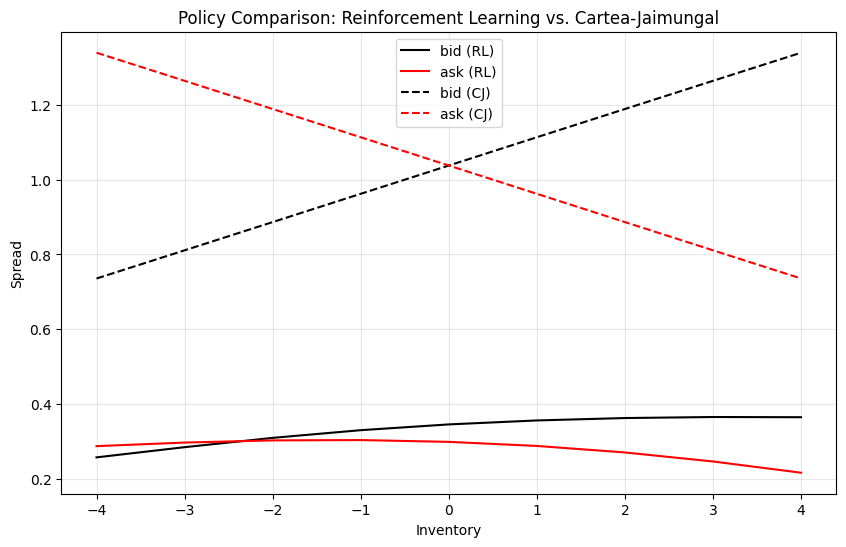

In [45]:
# Create a policy comparison plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(inventories, bid_actions, label="bid (RL)", color="k")
ax.plot(inventories, ask_actions, label="ask (RL)", color="r")
ax.plot(inventories, cj_bid_actions, label="bid (CJ)", color="k", linestyle="--")
ax.plot(inventories, cj_ask_actions, label="ask (CJ)", color="r", linestyle="--")
ax.legend()
ax.set_xlabel("Inventory")
ax.set_ylabel("Spread")
ax.set_title("Policy Comparison: Reinforcement Learning vs. Cartea-Jaimungal")
ax.grid(alpha=0.3)

# Ensure the directory exists
os.makedirs(best_model_path, exist_ok=True)

# Save the figure to the best model path
policy_comparison_filename = os.path.join(best_model_path, "policy_comparison.png")
fig.savefig(policy_comparison_filename, dpi=300, bbox_inches='tight')
print(f"Policy comparison plot saved to {policy_comparison_filename}")

### Dependence of policy on time

In [46]:


# Function to create the plot comparing PPO and CJ agents
def plot_policy_time_dependence(ppo_agent, cj_agent):
    # Time points to evaluate
    times = np.linspace(0, terminal_time, n_steps+1)  
    inventories = np.array([-3, -2, -1, 0, 1, 2, 3])
    
    # Colors for different inventory levels
    colors = {
        -3: 'blue',
        -2: 'orange',
        -1: 'green',
        0: 'red',
        1: 'salmon',
        2: 'purple',
        3: 'brown'
    }
    
    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1])
    
    ax1 = plt.subplot(gs[0, 0])  
    ax2 = plt.subplot(gs[0, 1])  
    ax3 = plt.subplot(gs[1, 0])  
    ax4 = plt.subplot(gs[1, 1])
    
    price = 100.0  
    if use_normalized_agent:
        price_normalized = 0  
    else:
        price_normalized = price  

    # For each inventory level
    for inv in inventories:
        rl_bids = []
        rl_asks = []
        cj_bids = []
        cj_asks = []
        
        inv_normalised = normalize_inventory(inv, max_inventory, use_normalized=use_normalized_agent, inverse=False)

        # For each time point
        for t in times:
            if use_normalized_agent:
                normalized_time = (t) / (1/2) - 1
            else:   
                normalized_time = t
            
            # Get PPO agent's actions
            rl_bid, rl_ask = ppo_agent.get_action(np.array([[inv_normalised, normalized_time, price_normalized]])).reshape(-1)
            rl_bids.append(rl_bid)
            rl_asks.append(rl_ask)
            
            # Get CJ agent's actions
            cj_bid, cj_ask = cj_agent.get_action(np.array([[0, inv, t, price]])).reshape(-1)
            cj_bids.append(cj_bid)
            cj_asks.append(cj_ask)
        
        # Plot the data
        ax1.plot(times, rl_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax2.plot(times, cj_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax3.plot(times, rl_asks, label=f"Inventory = {inv}", color=colors[inv])
        ax4.plot(times, cj_asks, label=f"Inventory = {inv}", color=colors[inv])
    
    ax1.set_title("RL δ^bid")
    ax2.set_title("CJP δ^bid")
    ax3.set_title("RL δ^ask")
    ax4.set_title("CJP δ^ask")
    
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel("Time (secs)")
        ax.set_xlim(0, terminal_time)
        ax.grid(True, alpha=0.3)
    
    ax1.legend()
    
    plt.suptitle("Dependence of policy on time", fontsize=16)
    plt.tight_layout()
    
    fig.text(0.5, 0.01, "Figure 5: Learnt PPO agent versus CarteaJaimungalAgent as a function of time.", 
             ha='center', fontsize=12)
    
    plt.show()

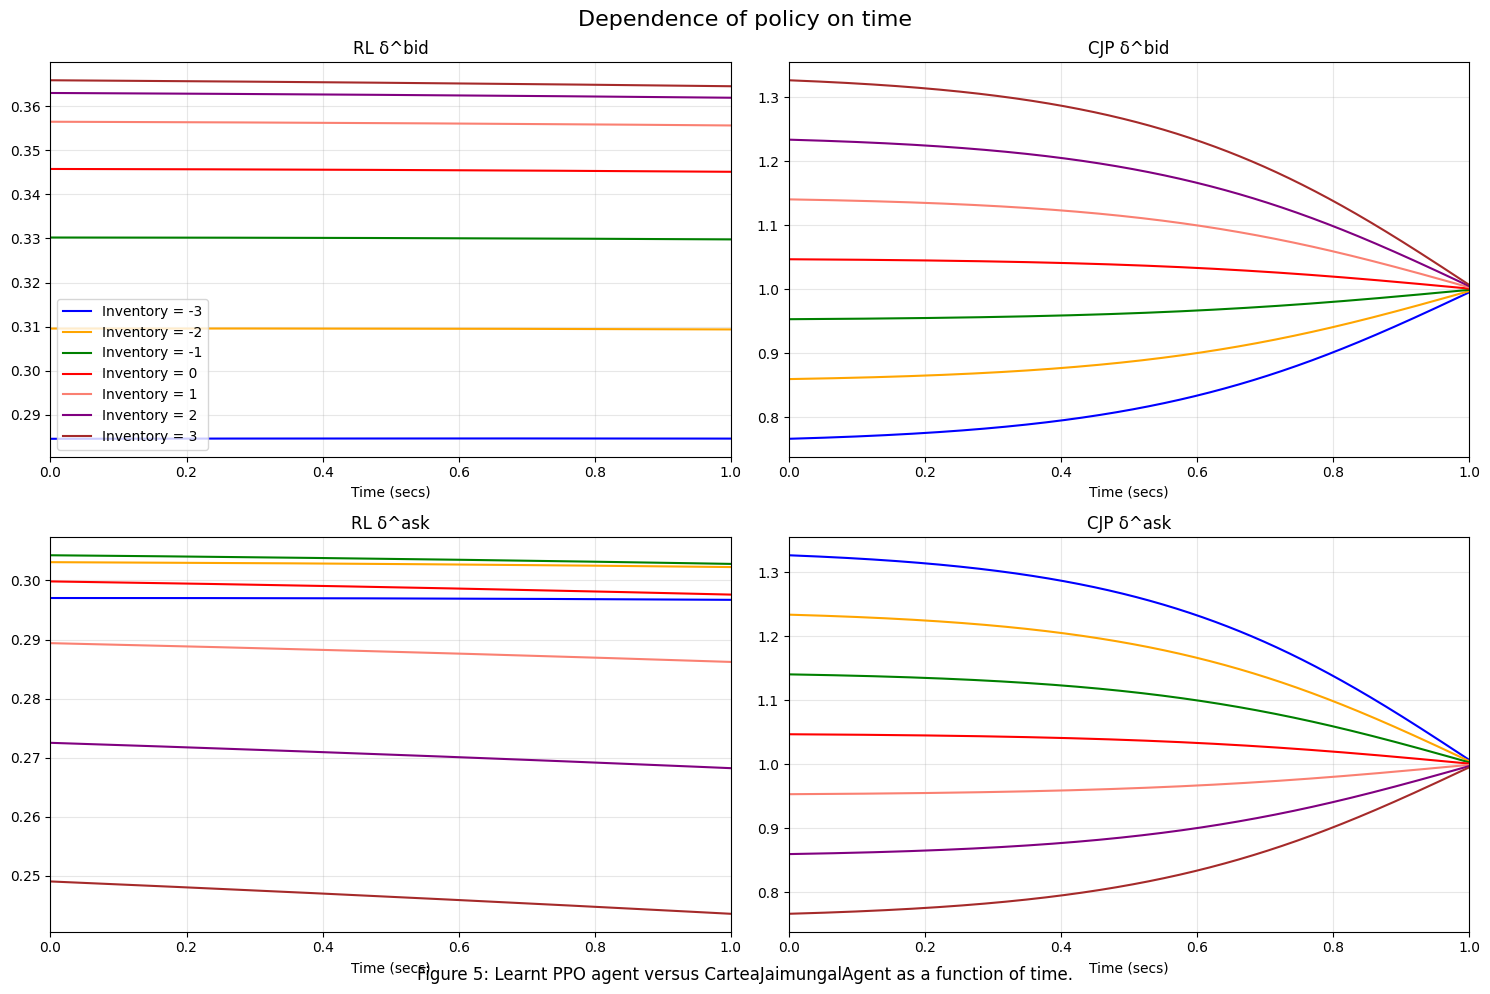

In [47]:
plot_policy_time_dependence(ppo_agent, cj_agent)

In [48]:
def plot_policy_time_dependence(ppo_agent, cj_agent):
    # Time points to evaluate
    times = np.linspace(0, terminal_time, n_steps+1)  
    inventories = np.array([-3, -2, -1, 0, 1, 2, 3])
    
    # Colors for different inventory levels
    colors = {
        -3: 'blue',
        -2: 'orange',
        -1: 'green',
        0: 'red',
        1: 'salmon',
        2: 'purple',
        3: 'brown'
    }
    
    # Create figure with 2x2 subplots
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, width_ratios=[1, 1])
    
    ax1 = plt.subplot(gs[0, 0])  
    ax2 = plt.subplot(gs[0, 1]) 
    ax3 = plt.subplot(gs[1, 0])  
    ax4 = plt.subplot(gs[1, 1]) 
    
    price = 100.0  
    if use_normalized_agent:
        price_normalized = 0  
    else:
        price_normalized = price  

    global_min = float('inf')
    global_max = float('-inf')
    
    all_data = []

    # For each inventory level
    for inv in inventories:
        rl_bids = []
        rl_asks = []
        cj_bids = []
        cj_asks = []
        
        inv_normalised = normalize_inventory(inv, max_inventory, use_normalized=use_normalized_agent, inverse=False)

        # For each time point
        for t in times:
            if use_normalized_agent:
                normalized_time = (t) / (1/2) - 1
            else:   
                normalized_time = t
            
            # Get PPO agent's actions
            rl_bid, rl_ask = ppo_agent.get_action(np.array([[inv_normalised, normalized_time, price_normalized]])).reshape(-1)
            rl_bids.append(rl_bid)
            rl_asks.append(rl_ask)
            
            # Get CJ agent's actions
            cj_bid, cj_ask = cj_agent.get_action(np.array([[0, inv, t, price]])).reshape(-1)
            cj_bids.append(cj_bid)
            cj_asks.append(cj_ask)
        
        global_min = min(global_min, min(rl_bids), min(rl_asks), min(cj_bids), min(cj_asks))
        global_max = max(global_max, max(rl_bids), max(rl_asks), max(cj_bids), max(cj_asks))
        
        all_data.append((inv, rl_bids, rl_asks, cj_bids, cj_asks))
    
    for inv, rl_bids, rl_asks, cj_bids, cj_asks in all_data:
        ax1.plot(times, rl_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax2.plot(times, cj_bids, label=f"Inventory = {inv}", color=colors[inv])
        ax3.plot(times, rl_asks, label=f"Inventory = {inv}", color=colors[inv])
        ax4.plot(times, cj_asks, label=f"Inventory = {inv}", color=colors[inv])
    
    # Apply the same y-axis limits to all subplots
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_ylim(global_min, global_max)
    
    ax1.set_title("RL δ^bid")
    ax2.set_title("CJP δ^bid")
    ax3.set_title("RL δ^ask")
    ax4.set_title("CJP δ^ask")
    
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel("Time (secs)")
        ax.set_xlim(0, terminal_time)
        ax.grid(True, alpha=0.3)
    
    ax1.legend()
    
    plt.suptitle("Dependence of policy on time", fontsize=16)
    plt.tight_layout()
    
    fig.text(0.5, 0.01, "Figure 5: Learnt PPO agent versus CarteaJaimungalAgent as a function of time.", 
             ha='center', fontsize=12)
    
    plt.show()
    return fig

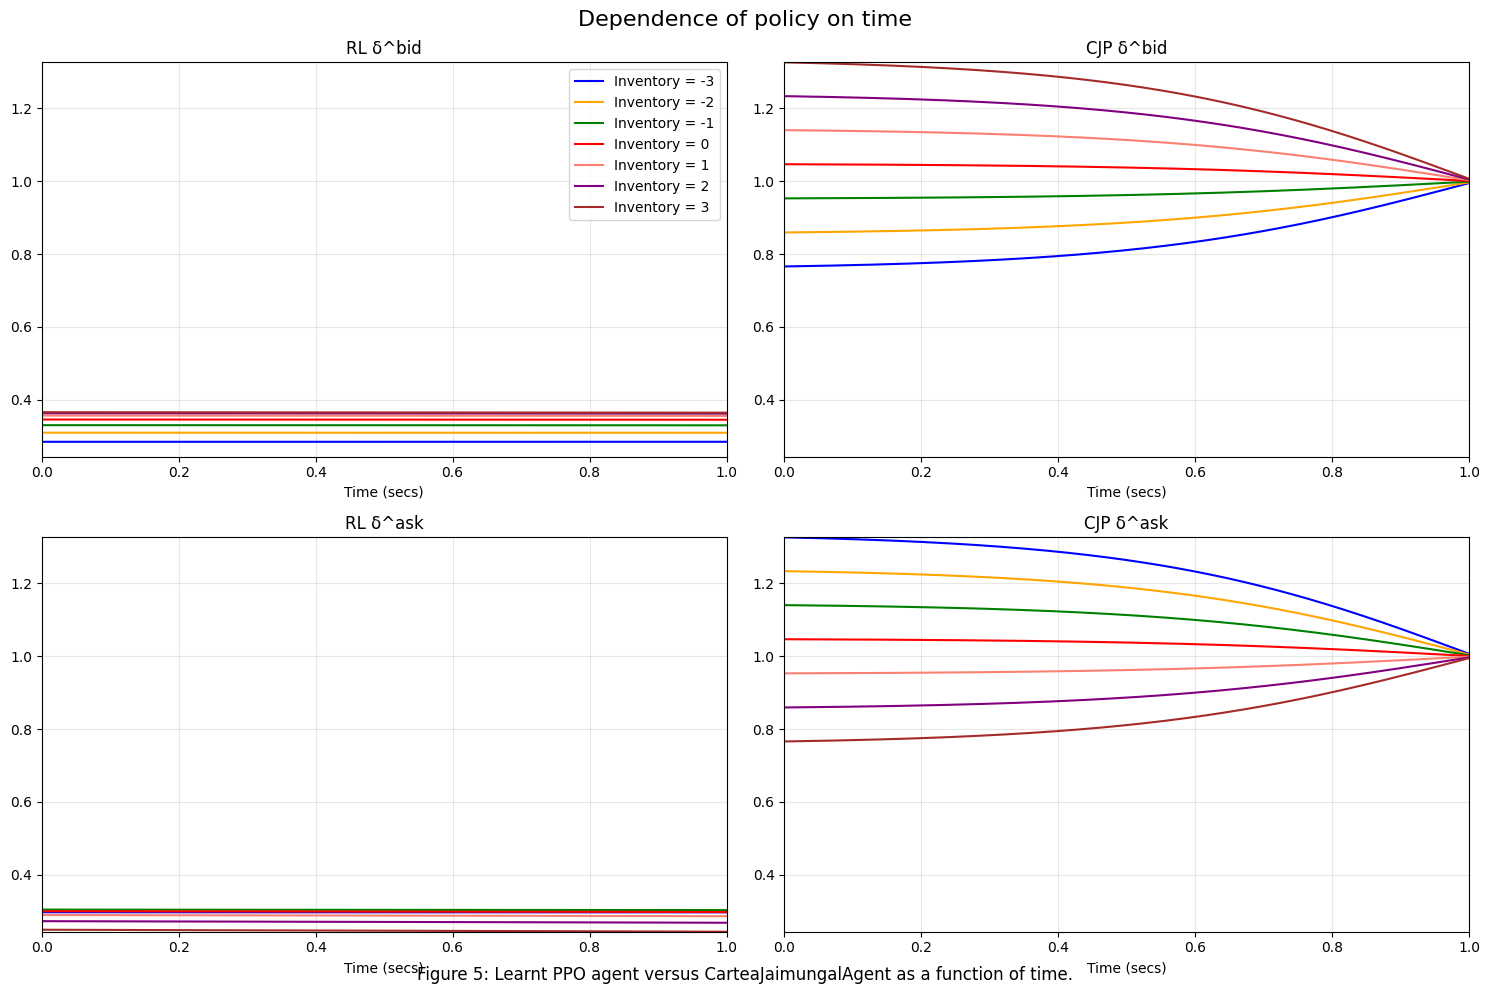

Plot saved to .././CJ_models/PPO-best/CjMm_final_version_prova/2025-12-01_11-52-23/policy_time_dependence.png


In [49]:
# Ensure the directory exists
os.makedirs(best_model_path, exist_ok=True)

# Create the plot
fig = plot_policy_time_dependence(ppo_agent, cj_agent)

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "policy_time_dependence.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

In [50]:
import glob
import os

def get_latest_event_file(logdir: str) -> str:
    # Recursively search for TensorBoard event files
    pattern = os.path.join(logdir, "**", "events.out.tfevents.*")
    event_files = glob.glob(pattern, recursive=True)
    if not event_files:
        raise FileNotFoundError(f"No TensorBoard event files found under {logdir}")
    # Pick the most recently modified one
    latest_file = max(event_files, key=os.path.getmtime)
    return latest_file

Using event file: .././CJ_models/tensorboard/PPO-learning/CjMm_final_version_prova/2025-12-01_11-52-23/PPO_1/events.out.tfevents.1764586345.MacBookAir.lan.55361.0


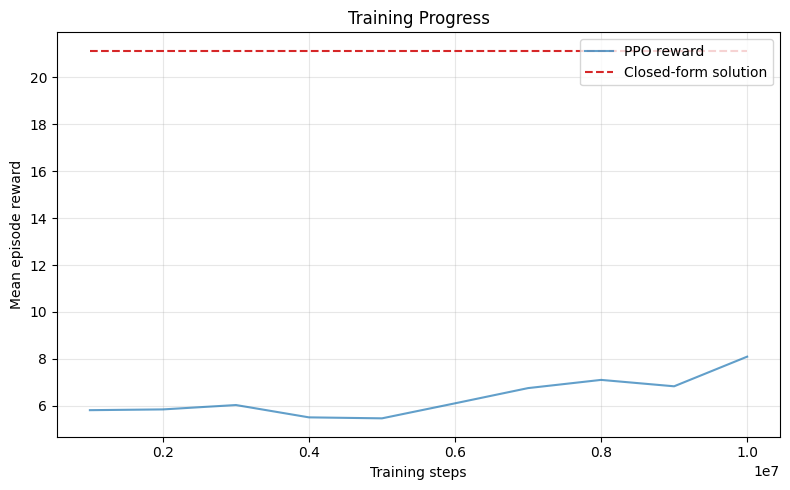

Plot saved to .././CJ_models/PPO-best/CjMm_final_version_prova/2025-12-01_11-52-23/Training_process_rollout_reward.png


In [51]:
# Load the event file
event_file = get_latest_event_file(tensorboard_logdir)
print(f"Using event file: {event_file}")

# Load the data
ea = event_accumulator.EventAccumulator(event_file)
ea.Reload()
# Extract the rollout/ep_rew_mean data
tag = "rollout/ep_rew_mean"
events = ea.Scalars(tag)
steps = [event.step for event in events]
rewards = [event.value for event in events]

# Plot the rewards
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the rewards
ax.plot(steps, rewards, '-', color='tab:blue', label='PPO reward', alpha=0.7)

# Add the baseline from Cartea-Jaimungal
y_line = float(results_cj["Mean PnL"].iloc[0])
ax.hlines(y=y_line, xmin=min(steps), xmax=max(steps), 
          linestyles='--', color='tab:red',
          label='Closed-form solution')

# Formatting
plt.grid(alpha=0.3)
plt.xlabel('Training steps')
plt.ylabel('Mean episode reward')
plt.title('Training Progress')
plt.legend()
plt.tight_layout()
plt.show()

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "Training_process_rollout_reward.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

Using event file: .././CJ_models/tensorboard/PPO-learning/CjMm_final_version_prova/2025-12-01_11-52-23/PPO_1/events.out.tfevents.1764586345.MacBookAir.lan.55361.0
{'images': [], 'audio': [], 'histograms': [], 'scalars': ['eval/mean_ep_length', 'eval/mean_reward', 'rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/std', 'train/value_loss'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


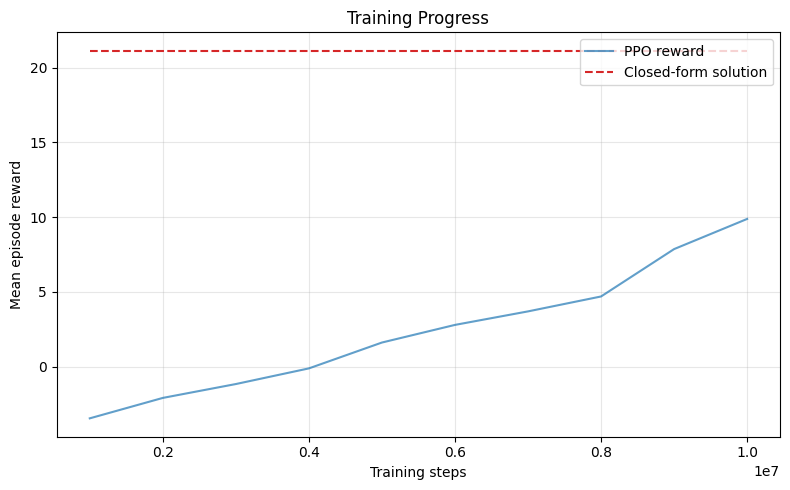

Plot saved to .././CJ_models/PPO-best/CjMm_final_version_prova/2025-12-01_11-52-23/Training_process_eval_reward.png


In [52]:
# Load the event file
event_file = get_latest_event_file(tensorboard_logdir)
print(f"Using event file: {event_file}")
ea = event_accumulator.EventAccumulator(event_file)
ea.Reload()
# Extract the eval/ep_rew_mean data
tag = "eval/mean_reward"
print(ea.Tags())
events = ea.Scalars(tag)
steps = [event.step for event in events]
rewards = [event.value for event in events]

# Plot the rewards
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the rewards
ax.plot(steps, rewards, '-', color='tab:blue', label='PPO reward', alpha=0.7)

# Add the baseline from Cartea-Jaimungal
y_line = float(results_cj["Mean PnL"].iloc[0])
ax.hlines(y=y_line, xmin=min(steps), xmax=max(steps), 
          linestyles='--', color='tab:red',
          label='Closed-form solution')

# Formatting
plt.grid(alpha=0.3)
plt.xlabel('Training steps')
plt.ylabel('Mean episode reward')
plt.title('Training Progress')
plt.legend()
plt.tight_layout()
plt.show()

# Save the figure to the best model path
plot_filename = os.path.join(best_model_path, "Training_process_eval_reward.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")

Using event file: .././CJ_models/tensorboard/PPO-learning/CjMm_final_version_prova/2025-12-01_11-52-23/PPO_1/events.out.tfevents.1764586345.MacBookAir.lan.55361.0
Available tags: {'images': [], 'audio': [], 'histograms': [], 'scalars': ['eval/mean_ep_length', 'eval/mean_reward', 'rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/std', 'train/value_loss'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


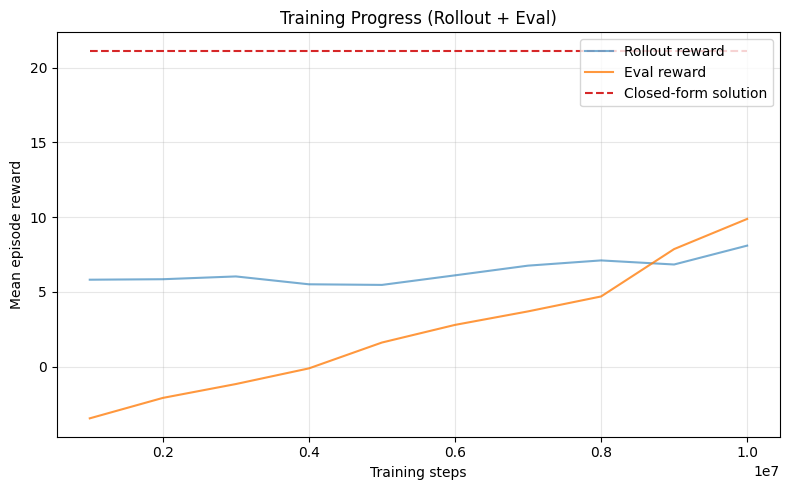

Plot saved to .././CJ_models/PPO-best/CjMm_final_version_prova/2025-12-01_11-52-23/Training_process_rewards.png


In [53]:
# === Load rollout rewards ===
rollout_file = get_latest_event_file(tensorboard_logdir)
print(f"Using event file: {rollout_file}")
# Load the data
ea_rollout = event_accumulator.EventAccumulator(rollout_file)
ea_rollout.Reload()

# === Load eval rewards ===
eval_file = rollout_file  # same file if training and eval in same run
ea_eval = event_accumulator.EventAccumulator(eval_file)
ea_eval.Reload()

# Extract rollout and eval data
rollout_tag = "rollout/ep_rew_mean"
eval_tag = "eval/mean_reward"

# Make sure both tags exist
print("Available tags:", ea_rollout.Tags())

rollout_events = ea_rollout.Scalars(rollout_tag)
eval_events = ea_eval.Scalars(eval_tag)

rollout_steps = [e.step for e in rollout_events]
rollout_rewards = [e.value for e in rollout_events]

eval_steps = [e.step for e in eval_events]
eval_rewards = [e.value for e in eval_events]

# === Plot both ===
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(rollout_steps, rollout_rewards, '-', color='tab:blue', label='Rollout reward', alpha=0.6)
ax.plot(eval_steps, eval_rewards, '-', color='tab:orange', label='Eval reward', alpha=0.8)

# Add baseline line
y_line = float(results_cj["Mean PnL"].iloc[0])
ax.hlines(y=y_line, xmin=min(rollout_steps + eval_steps), xmax=max(rollout_steps + eval_steps),
          linestyles='--', color='tab:red', label='Closed-form solution')

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Training Progress (Rollout + Eval)')
ax.legend()
plt.tight_layout()
plt.show()

# Save the figure
plot_filename = os.path.join(best_model_path, "Training_process_rewards.png")
fig.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")
